# Featurize After Bond Specific orthogonal TB

In [1]:
import pickle
import os
import glob
import numpy as np
import pdb
import pandas as pd
from importlib.machinery import SourceFileLoader
import re
from tqdm.notebook import tqdm_notebook
from BopFoxFeaturizer.brief_summary_parser import StructSummaryParser
from BopFoxFeaturizer.FeatureConcatenate import stackdata

In [2]:
# Original DFT Data
briefsummary_files = pd.Series(glob.glob('**/briefsummary*.dat',recursive=True))
Parser = StructSummaryParser()#.concat_briefsummaries(briefsummary_files)
BS = Parser.BriefSummary

# the moments I calculated in some other ocasion - NSC canonical tight binding model
BondSpecific = pd.read_pickle('RESULTS_NSC_BOND_SPECIFIC.pkl')

BondSpecific.drop(columns=['NSC_U_bond_atom_list'], inplace=True)
# Atomic Averages:

BondSpecific.dropna(how='any',inplace=True)

M = BondSpecific['NSC_moments'].map(lambda M: np.array(M).mean(axis=0))
S = BondSpecific['NSC_SIGMA'].map(lambda M: np.array(M).mean(axis=0))
Binf=BondSpecific['NSC_Binf'].map(lambda s: [float(si) for si in s]).map(np.mean)
Ainf=BondSpecific['NSC_Ainf'].map(lambda s: [float(si) for si in s]).map(np.mean)
AN = BondSpecific['NSC_an'].map(lambda M: np.array(M).mean(axis=0))
BN = BondSpecific['NSC_bn'].map(lambda M: np.array(M).mean(axis=0))
BOP_atom_average = pd.concat([M, S, AN, BN, Ainf, Binf], axis=1)
# Feature Transformation to concatenation
BOP, names = stackdata(BOP_atom_average, BOP_atom_average.columns.values)
BOP = pd.DataFrame(data=BOP, columns=names, index = BOP_atom_average.index)
BOP['NSC_U_bind'] = BondSpecific['NSC_U_bind'].map(float)

del M, S, Binf, Ainf, AN, BN, BondSpecific, BOP_atom_average # now I donnt need any more individual columns

# Some Machine Learning

In [3]:
from seaborn import heatmap
from sklearn.kernel_ridge import KernelRidge
import matplotlib.pyplot as plt
plt.style.use('seaborn')
plt.rc('figure', figsize=(20,15))
plt.rc('legend',fontsize=24)
plt.rc('axes',labelsize=28)
plt.rc('xtick',labelsize=24)
plt.rc('ytick',labelsize=24)

# Targets


In [4]:
groundstates = {'Re_pv':-12.44533, 'Ni_pv':-5.726500, 'Al':-3.745590, 'Co':-7.107694, 'W_pv':-12.960454,'':0}
from BopFoxFeaturizer.Featurizer import Featurizer
#featurizer=SourceFileLoader(
#    'featurizer',
#    'bopfoxfeaturizer/BopFoxFeaturizer/Featurizer.py'
#).load_module().Featurizer(BS)
BS['EF'] = Featurizer(BS).get_formation_energy(ground_states_dic=groundstates)
BS = BS.dropna()

I am not actually using this ?

In [5]:
def getfloat(s):
    try:
        return float(s)
    except Exception as E:
        return np.NaN

BS['B0']=BS['B0'].map(getfloat)

In [6]:
DATA = BOP.copy()
DATA[['B0','V0','EF']]=BS[['B0','V0','EF']]

In [7]:
Original = pd.read_pickle('data_complete_features.pkl')
Original['B0']=Original['B0'].map(getfloat)
Original['V0']=Original['V0'].map(getfloat)

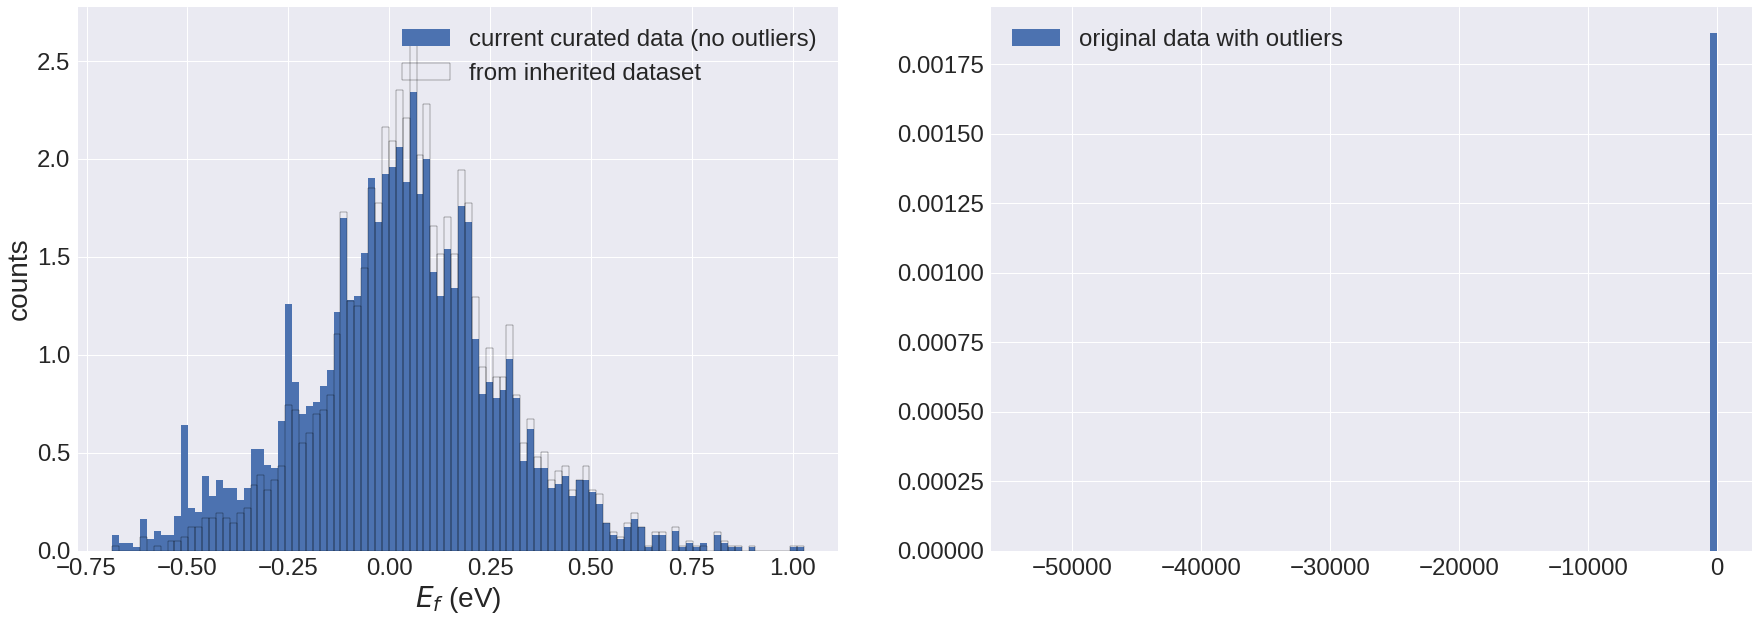

In [8]:
fig, ax = plt.subplots(1,2,figsize=(30,10))
h1=BS[BS['EF']>-10][BS['EF']<10]['EF'].hist(bins=100, ax=ax[0],density=True,label='current curated data (no outliers)')
h2=Original['E_f'].hist(bins=100,fill=None, density=True, ax = ax[0], label='from inherited dataset')
ax[0].legend()
ax[0].set_xlabel('$E_f$ (eV)')
ax[0].set_ylabel('counts')
h3=BS['EF'].hist(bins=100, fill='k', ax=ax[1], density=True, label='original data with outliers')
l = ax[1].legend()

In [9]:
DATA = DATA[DATA['EF']>-10][DATA['EF']<10]

In [10]:
DATA = DATA[ DATA['B0']<600 ]

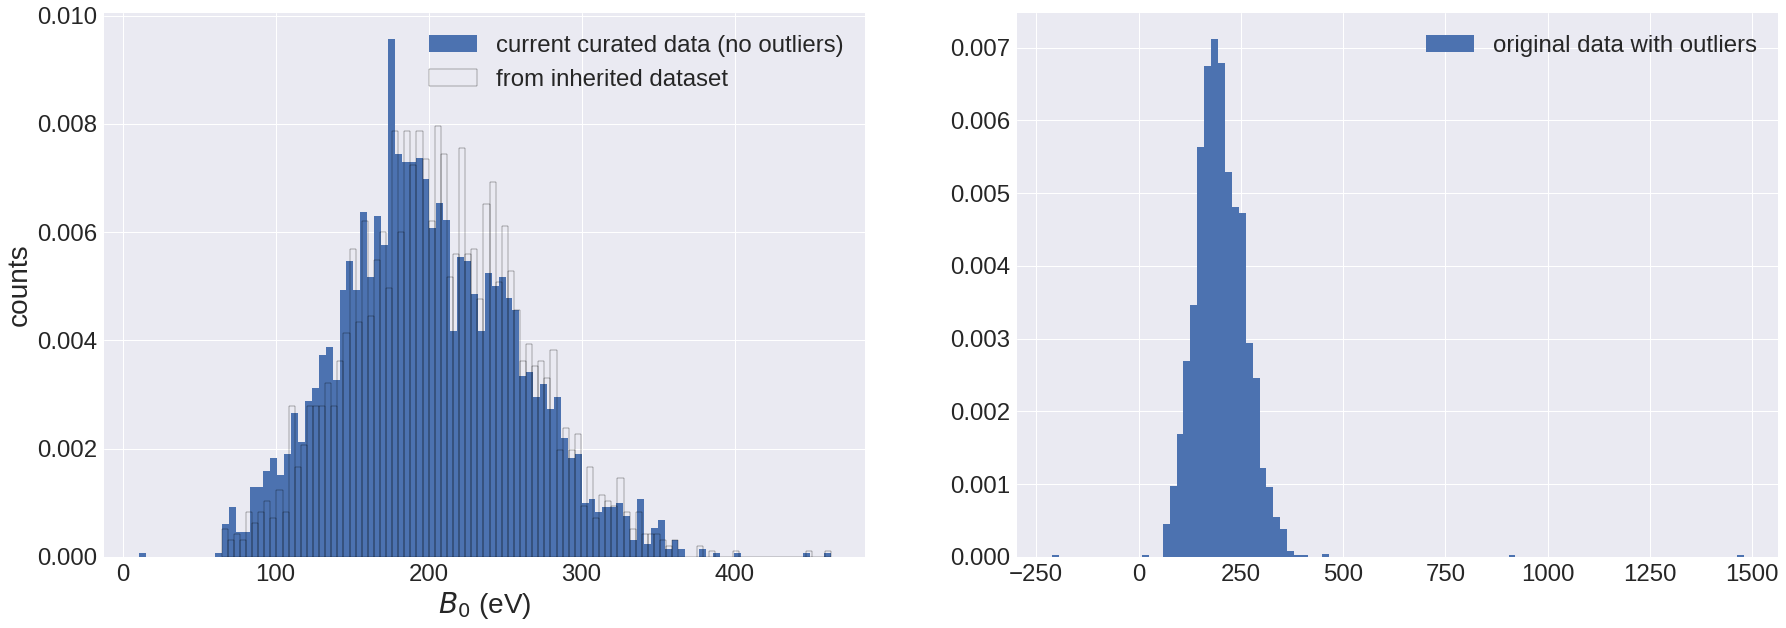

In [11]:
fig, ax = plt.subplots(1,2,figsize=(30,10))
h1=BS[BS['B0']<600][BS['B0']>0]['B0'].hist(bins=100, ax=ax[0],density=True,label='current curated data (no outliers)')
h2=Original['B0'].hist(bins=100,fill=None, density=True, ax = ax[0], label='from inherited dataset')
ax[0].legend()
ax[0].set_xlabel('$B_0$ (eV)')
ax[0].set_ylabel('counts')
h3=BS['B0'].hist(bins=100, fill='k', ax=ax[1], density=True, label='original data with outliers')
l = ax[1].legend()

In [12]:
DATA['B0']=DATA[DATA['B0']<600][DATA['B0']>0]['B0']

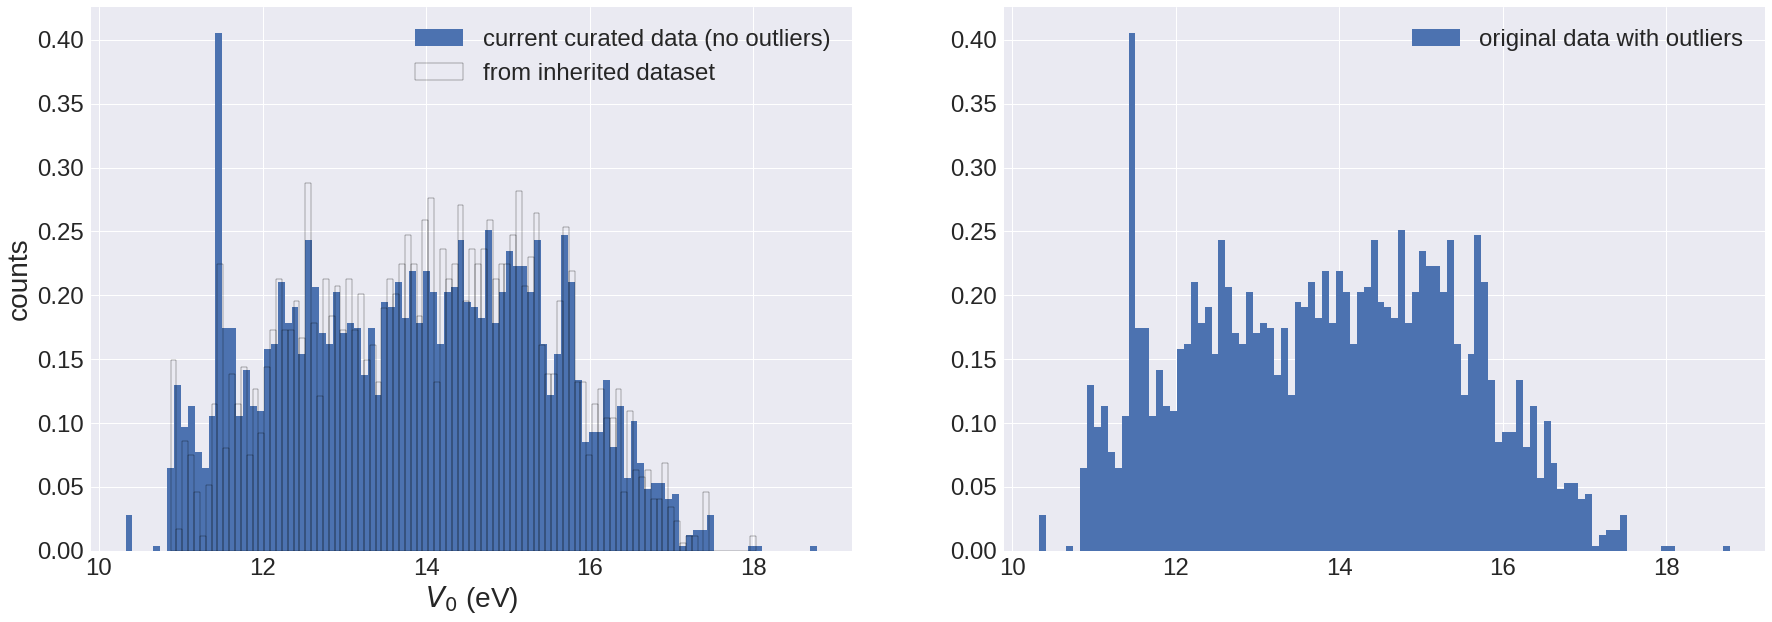

In [13]:
fig, ax = plt.subplots(1,2,figsize=(30,10))
h1=BS['V0'].hist(bins=100, ax=ax[0],density=True,label='current curated data (no outliers)')
h2=Original['V0'].hist(bins=100,fill=None, density=True, ax = ax[0], label='from inherited dataset')
ax[0].legend()
ax[0].set_xlabel('$V_0$ (eV)')
ax[0].set_ylabel('counts')
h3=BS['V0'].hist(bins=100, fill='k', ax=ax[1], density=True, label='original data with outliers')
l = ax[1].legend()

## no filter needed.

```python
DATA=DATA[DATA['NSC_moments_1']<1e4]
DATA.shape
DATA=DATA[abs(DATA['NSC_moments_2'])<15e4]
DATA.shape
DATA[abs(DATA['NSC_moments_3'])<8e7]['NSC_moments_3'].hist(bins=100)
DATA[abs(DATA['NSC_moments_3'])<8e7]['NSC_moments_3'].
DATA=DATA[abs(DATA['NSC_moments_4'])<1.5e5]
DATA[abs(DATA['NSC_moments_4'])<1.5e5]['NSC_moments_4'].hist(bins=100)
```

# Histograms of features

Are there more outliers ?

In [14]:
columns = DATA.columns.drop(['B0', 'V0', 'EF'])

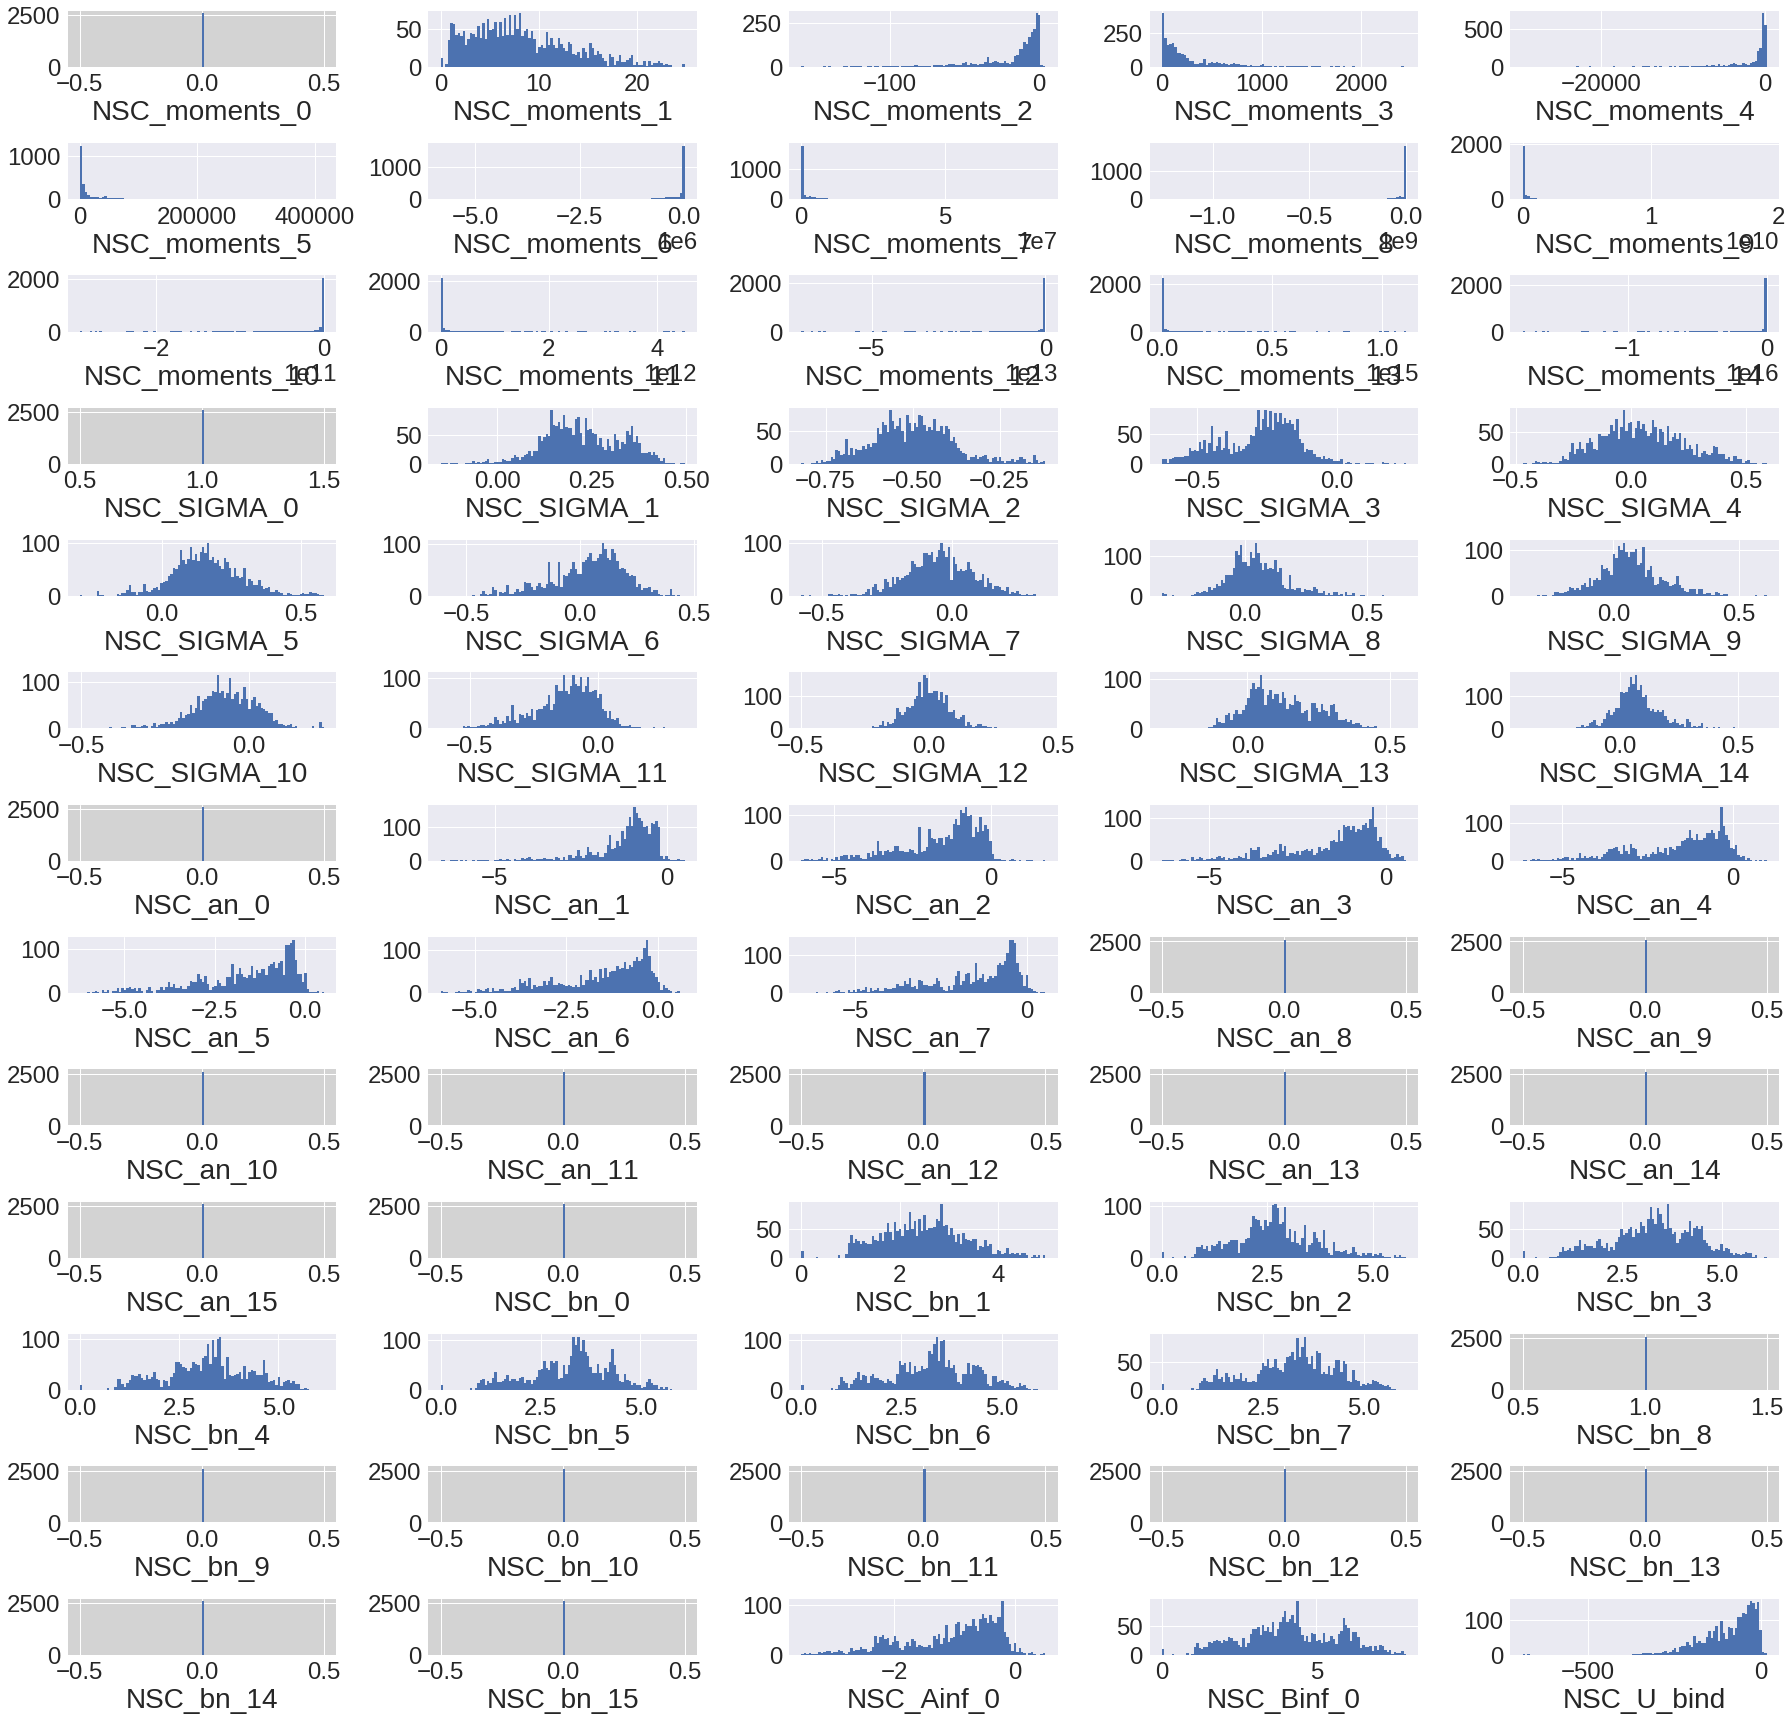

In [15]:
feature = []
fig = plt.figure(figsize=(25, 25))
for c, col in enumerate(columns):
    ax = fig.add_subplot( len(columns)/5+1, 5, c+1 )
    bins = plt.hist(DATA[col], bins=100)
    
    if sum( bins[0]>0 ) > 1:
        feature.append(col)
    else:
        ax.set_facecolor('lightgray')
           
    plt.xlabel(col,y=0.8 )
fig.tight_layout()
    
    

Can somewhat classify the structures from the moments?

# Classification and weighting

In [16]:
with open('structures/binary/list.bcc', 'r') as f:
    listbcc = f.readlines()[0].strip().split(' ')

listbcc = ' '.join([re.sub('-.*','',s) for s in listbcc])

with open('structures/binary/list.fcc', 'r') as f:
    listfcc = f.readlines()[0].strip().split(' ')

listfcc = ' '.join([re.sub('-.*','',s) for s in listfcc])

with open('structures/binary/list.hcp', 'r') as f:
    listhcp = f.readlines()[0].strip().split(' ')

listhcp = ' '.join ([re.sub('-.*','',s) for s in listhcp])

Target_Class = pd.Series(
    DATA.index.str.split('.').map(lambda l: l[1]).map(lambda s: s.split('-')[0]),
    index=DATA.index
)

Target_Class[Target_Class.map(lambda s: s in listhcp)]='hcp'
Target_Class[Target_Class.map(lambda s: s in listfcc)]='fcc'
Target_Class[Target_Class.map(lambda s: s in listbcc)]='bcc'

Target_Class[DATA.index.str.contains('SQS-fcc')] = 'fcc'
Target_Class[DATA.index.str.contains('SQS-L12')] = 'fcc'

Target_Class[    
    Target_Class.str.contains('Al42W') |\
    Target_Class.str.contains('Al9Co2') |\
    Target_Class.str.contains('Al5W') |\
    Target_Class.str.contains('Al12W') |\
    Target_Class.str.contains('Al4W') |\
    Target_Class.str.contains('Al5Co2')
] = 'others'


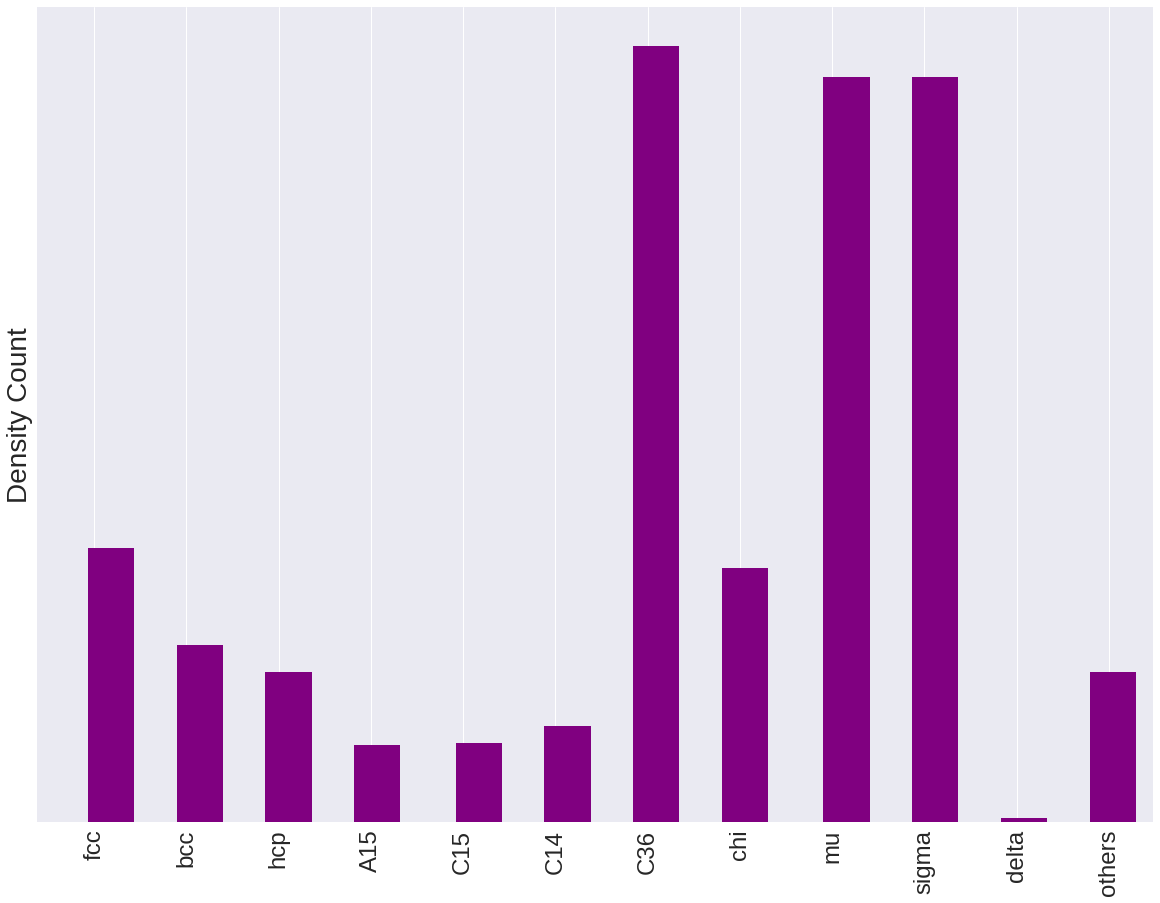

In [17]:
plt.hist(Target_Class, bins=80, density = True, width=0.5, align='left', color = 'purple')
xticks = plt.xticks(rotation=90)
yticks = plt.yticks([])
plt.ylabel('Density Count')
plt.savefig('class_counts.pdf')

as we see here, the dataset is quite vadly classified, this will lead to wrong results when I try to regress A15 properties using the rest of the dataset. ths classes should be taken into account and give the weights to the regressors

In [18]:
# only the features with some distributino:

In [19]:
print(feature)

['NSC_moments_1', 'NSC_moments_2', 'NSC_moments_3', 'NSC_moments_4', 'NSC_moments_5', 'NSC_moments_6', 'NSC_moments_7', 'NSC_moments_8', 'NSC_moments_9', 'NSC_moments_10', 'NSC_moments_11', 'NSC_moments_12', 'NSC_moments_13', 'NSC_moments_14', 'NSC_SIGMA_1', 'NSC_SIGMA_2', 'NSC_SIGMA_3', 'NSC_SIGMA_4', 'NSC_SIGMA_5', 'NSC_SIGMA_6', 'NSC_SIGMA_7', 'NSC_SIGMA_8', 'NSC_SIGMA_9', 'NSC_SIGMA_10', 'NSC_SIGMA_11', 'NSC_SIGMA_12', 'NSC_SIGMA_13', 'NSC_SIGMA_14', 'NSC_an_1', 'NSC_an_2', 'NSC_an_3', 'NSC_an_4', 'NSC_an_5', 'NSC_an_6', 'NSC_an_7', 'NSC_bn_1', 'NSC_bn_2', 'NSC_bn_3', 'NSC_bn_4', 'NSC_bn_5', 'NSC_bn_6', 'NSC_bn_7', 'NSC_Ainf_0', 'NSC_Binf_0', 'NSC_U_bind']


In [20]:
Classes = pd.DataFrame(Target_Class.values, columns=['Class'], index=DATA.index)
Target_Class_Count = Target_Class.value_counts()
Classes['Weights'] = 1/(Target_Class_Count[Target_Class]/Target_Class_Count.sum()).values #Target_Class_Count.sum()

In [21]:
# only the features with some distributino:

print(feature)

['NSC_moments_1', 'NSC_moments_2', 'NSC_moments_3', 'NSC_moments_4', 'NSC_moments_5', 'NSC_moments_6', 'NSC_moments_7', 'NSC_moments_8', 'NSC_moments_9', 'NSC_moments_10', 'NSC_moments_11', 'NSC_moments_12', 'NSC_moments_13', 'NSC_moments_14', 'NSC_SIGMA_1', 'NSC_SIGMA_2', 'NSC_SIGMA_3', 'NSC_SIGMA_4', 'NSC_SIGMA_5', 'NSC_SIGMA_6', 'NSC_SIGMA_7', 'NSC_SIGMA_8', 'NSC_SIGMA_9', 'NSC_SIGMA_10', 'NSC_SIGMA_11', 'NSC_SIGMA_12', 'NSC_SIGMA_13', 'NSC_SIGMA_14', 'NSC_an_1', 'NSC_an_2', 'NSC_an_3', 'NSC_an_4', 'NSC_an_5', 'NSC_an_6', 'NSC_an_7', 'NSC_bn_1', 'NSC_bn_2', 'NSC_bn_3', 'NSC_bn_4', 'NSC_bn_5', 'NSC_bn_6', 'NSC_bn_7', 'NSC_Ainf_0', 'NSC_Binf_0', 'NSC_U_bind']


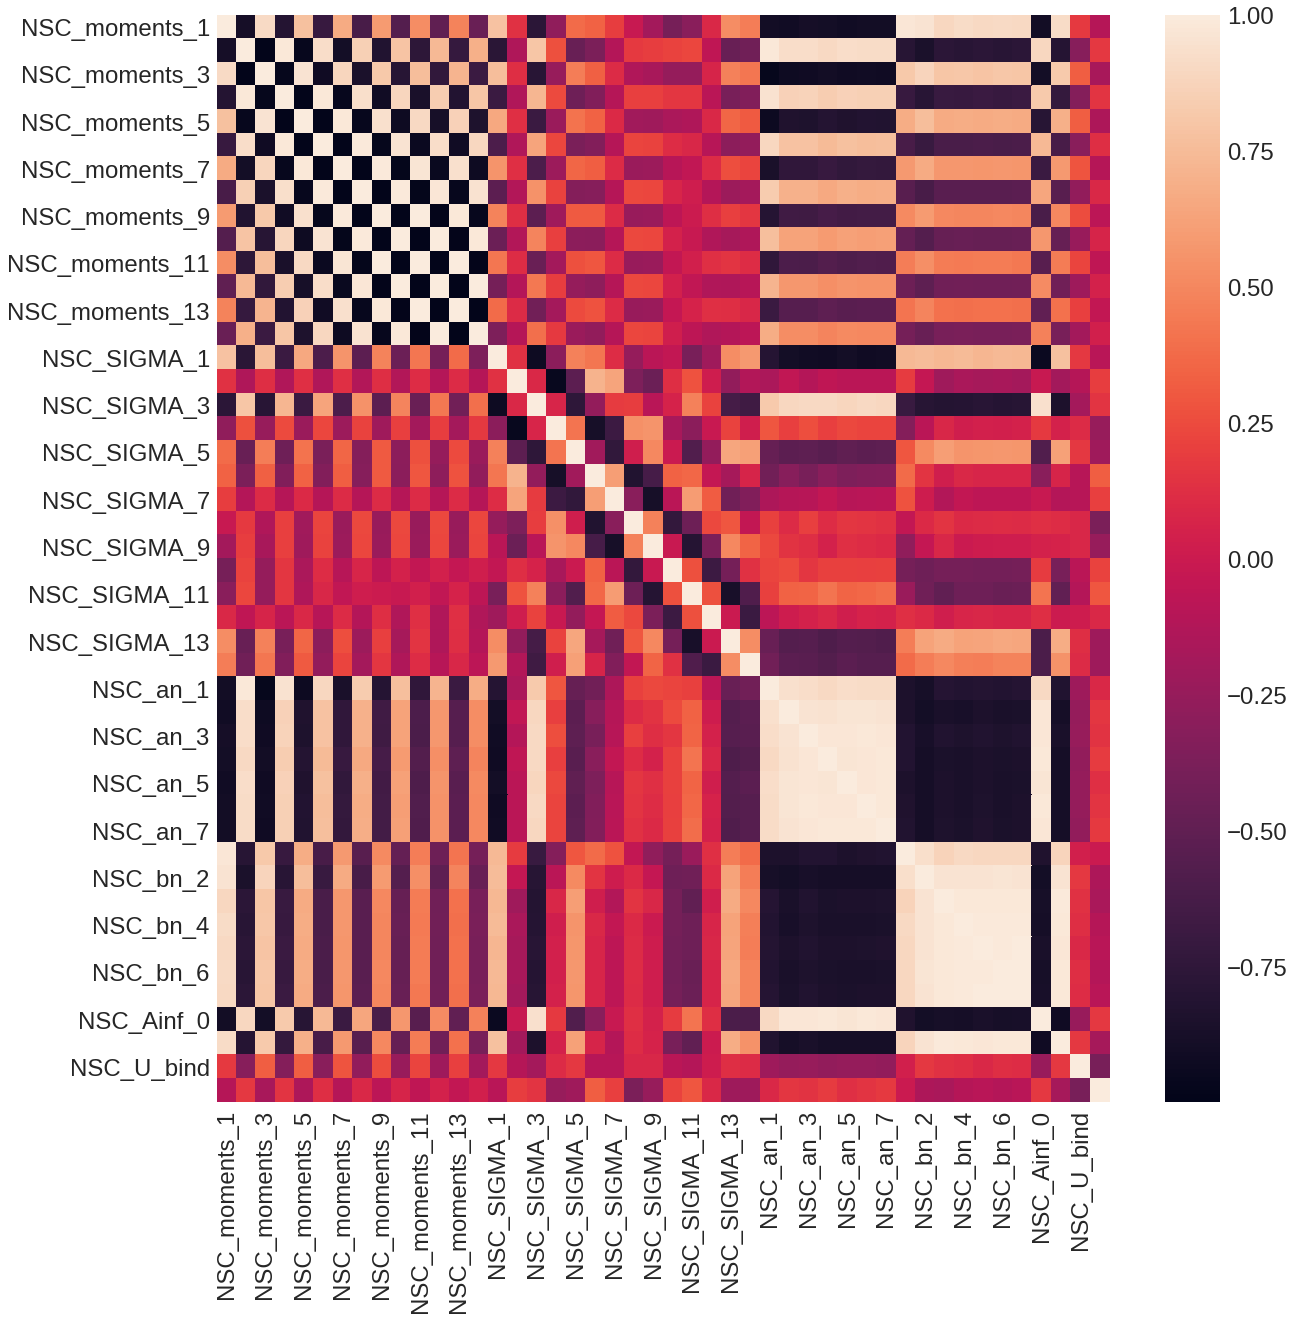

In [22]:
CORRS = DATA[feature+['EF']].corr()
CORRS.dropna(how='all',inplace=True)
CORRS.dropna(inplace=True, axis=1)
ax = plt.figure(figsize=(20,20)).add_axes()
HM = heatmap(CORRS, ax=ax)

I remove this because the scatterplot on so many features is really big and hard to visualize
```python
scatterplot = pd.plotting.scatter_matrix(DATA[feature],figsize=(30,30), diagonal='kde')
for a in range(scatterplot.shape[0]):
#    scatterplot[0,a].set_xlabel(axis.get_xlabel(), rotation=45) #,xy=(-1,0), xycoords='offset') 
    scatterplot[a,0].set_ylabel(scatterplot[a,0].get_ylabel(), rotation=30) 
    scatterplot[-1,a].set_xlabel(scatterplot[a,0].get_xlabel(), rotation=30)
plt.gcf().tight_layout()
```

# Test with Decision Tree Regressor

In [23]:
CORRS['EF'][CORRS['EF']<1].index.values

array(['NSC_moments_1', 'NSC_moments_2', 'NSC_moments_3', 'NSC_moments_4',
       'NSC_moments_5', 'NSC_moments_6', 'NSC_moments_7', 'NSC_moments_8',
       'NSC_moments_9', 'NSC_moments_10', 'NSC_moments_11',
       'NSC_moments_12', 'NSC_moments_13', 'NSC_moments_14',
       'NSC_SIGMA_1', 'NSC_SIGMA_2', 'NSC_SIGMA_3', 'NSC_SIGMA_4',
       'NSC_SIGMA_5', 'NSC_SIGMA_6', 'NSC_SIGMA_7', 'NSC_SIGMA_8',
       'NSC_SIGMA_9', 'NSC_SIGMA_10', 'NSC_SIGMA_11', 'NSC_SIGMA_12',
       'NSC_SIGMA_13', 'NSC_SIGMA_14', 'NSC_an_1', 'NSC_an_2', 'NSC_an_3',
       'NSC_an_4', 'NSC_an_5', 'NSC_an_6', 'NSC_an_7', 'NSC_bn_1',
       'NSC_bn_2', 'NSC_bn_3', 'NSC_bn_4', 'NSC_bn_5', 'NSC_bn_6',
       'NSC_bn_7', 'NSC_Ainf_0', 'NSC_Binf_0', 'NSC_U_bind'], dtype=object)

In [24]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from math import sqrt
from sklearn.metrics import r2_score

In [25]:
CORRS['EF'][CORRS['EF']<1].index.values

array(['NSC_moments_1', 'NSC_moments_2', 'NSC_moments_3', 'NSC_moments_4',
       'NSC_moments_5', 'NSC_moments_6', 'NSC_moments_7', 'NSC_moments_8',
       'NSC_moments_9', 'NSC_moments_10', 'NSC_moments_11',
       'NSC_moments_12', 'NSC_moments_13', 'NSC_moments_14',
       'NSC_SIGMA_1', 'NSC_SIGMA_2', 'NSC_SIGMA_3', 'NSC_SIGMA_4',
       'NSC_SIGMA_5', 'NSC_SIGMA_6', 'NSC_SIGMA_7', 'NSC_SIGMA_8',
       'NSC_SIGMA_9', 'NSC_SIGMA_10', 'NSC_SIGMA_11', 'NSC_SIGMA_12',
       'NSC_SIGMA_13', 'NSC_SIGMA_14', 'NSC_an_1', 'NSC_an_2', 'NSC_an_3',
       'NSC_an_4', 'NSC_an_5', 'NSC_an_6', 'NSC_an_7', 'NSC_bn_1',
       'NSC_bn_2', 'NSC_bn_3', 'NSC_bn_4', 'NSC_bn_5', 'NSC_bn_6',
       'NSC_bn_7', 'NSC_Ainf_0', 'NSC_Binf_0', 'NSC_U_bind'], dtype=object)

In [26]:
#param_grid = { 'alpha': np.linspace(0.001, 10,10),
#              'gamma': np.logspace(0,np.log10(100),10) }
param_grid = {'max_depth':np.arange(10,30) , 'min_samples_split':np.arange(10,30)}
features = CORRS['EF'][CORRS['EF']<1].index.values
from BopFoxFeaturizer.FeatureConcatenate import FeatureConcatenate
#FC = SourceFileLoader(
#    'FC',
#    'bopfoxfeaturizer/BopFoxFeaturizer/FeatureConcatenate.py'
#).load_module().FeatureConcatenate(DATA,DecisionTreeRegressor(), param_grid, features, data_target='EF')

In [27]:
Bestfeats, bestscores = FC.build_features_list(
    best_feature_proposal=['NSC_bn_1'],
    pass_force_refit=False,
    report_prefix='test1_',
)

NameError: name 'FC' is not defined

I would like to recover the model

In [ ]:
bestDecisionTree = FC.report['best_estimator'][0]

In [ ]:
bestDecisionTree

# MLPRegressor

In [ ]:
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import QuantileTransformer
from sklearn.pipeline import Pipeline

In [ ]:
mplr = Pipeline([( 'scaler', QuantileTransformer() ),
                 ('regressor', MLPRegressor(hidden_layer_sizes=(50,50),
                                           activation='relu',
                                           solver='lbfgs' )
                                           )
                ])

In [ ]:
columns

In [ ]:
param_grid={'regressor__alpha': [0.0001, 0.001, 0.01, 0.1], 'regressor__learning_rate_init': [0.001, 0.01, 0.1]}
FC2 = SourceFileLoader(
    'FC',
    'bopfoxfeaturizer/BopFoxFeaturizer/FeatureConcatenate.py'
).load_module().FeatureConcatenate(DATA, mplr,  param_grid, columns, data_target='EF')


In [ ]:
FORCE = False

In [ ]:
if os.path.exists('fittedmodels/bestMLPR.pkl') and not FORCE:
    with open('fittedmodels/bestMLPR.pkl', 'rb') as f:
        bestMLPR = pickle.load(f)
        BFeaturesMLP =pickle.load(f)
        scoresMLP = pickle.load(f)
else:
    BFeaturesMLP, scoresMLP = FC2.build_features_list(
        pass_force_refit=False,
        report_prefix='MLPR_',
    )
    with open('fittedmodels/bestMLPR.pkl', 'wb') as f:
        pickle.dump(FC2.report['best_estimator'][0],f)
        pickle.dump(BFeaturesMLP, f)
        pickle.dump(scoresMLP, f)

In [ ]:

#BFMPL, MSMPL = FC2.build_features_list(
#    pass_force_refit=True,
#    report_prefix='MLPR_',
#)

In [ ]:
BFMPL, MSMPL

In [ ]:
BESTMLP = FC2.report

In [ ]:
BESTMLP['best_estimator'][0]

# Somple plots for presentations

In [ ]:
FC.model.fit(DATA[Bestfeats],DATA['EF'])

In [ ]:
EPREDICT = FC.model.predict(DATA[Bestfeats],)

In [ ]:
import seaborn as sns

In [ ]:
#sns.lmplot(EPREDICT, DATA['EF'], hue=Target_Class)
ax = sns.scatterplot(
    EPREDICT,
    DATA['EF'],
    hue=Target_Class,
    sizes=np.abs(DATA['EF']-EPREDICT)
)
ax.set_ylabel('Target $E_f$')
ax.set_xlabel('Predicted $E_f$')
ax.plot(DATA['EF'], DATA['EF'], 'k', dashes=[10, 10,5])
plt.savefig('graph/Regresion_Example_BondSpecific.pdf')

In [ ]:
plt.plot(EPREDICT, DATA['EF'],'or', alpha=0.7)
plt.plot(DATA['EF'], DATA['EF'],'-k', alpha=0.7)
plt.ylabel('Predicted $E_f$', fontsize = 34)
plt.xlabel('Predicted $E_f$', fontsize = 34)
plt.ylabel('Training $E_f$')
plt.savefig('graph/Regresion_Example_simple_BondSpecific.pdf')

In [ ]:
plt.scatter(EPREDICT, DATA['EF'], c='r', alpha=0.7)
plt.plot(DATA['EF'], DATA['EF'],'-k', alpha=0.7)
plt.xlabel('Predicted $E_f$', fontsize = 28)
plt.xlabel('Predicted $E_f$', fontsize = 28)
plt.ylabel('Training $E_f$')
plt.savefig('Regresion_Example.pdf')

# Errors

In [ ]:
ERRORS = EPREDICT - DATA['EF']

In [ ]:
edges = plt.hist(ERRORS, bins=80,density=True)

In [ ]:
Classes

In [ ]:
#fig, axes = plt.subplots(3,)
#for index, clase in Classes.iterrows():
#e=plt.hist(ERRORS[Target_Class == 'mu'],density=True,bins=Classes[])
#    e=sns.histplot(ERRORS[Target_Class == clase['Class']],alpha=0.7,kde=True)

In [ ]:
e3 = plt.hist (ERRORS[Classes['Class']=='C36'],color = 'blue', density=True, bins=50, label='C36')
e2 = plt.hist (ERRORS[Classes['Class']=='sigma'],color='magenta', density=True, bins=50,label='sigma')
e = plt.hist(ERRORS[Classes['Class']=='mu'],color='darkgreen', density=True, bins = 50, label='$\mu$')

plt.ylabel('Density Counts')
plt.xlabel('$|  E_F^{predicted} -  E_F^{training} | $')
plt.legend()
plt.savefig('graph/Errors_main_BondSpecific.pdf')

In [ ]:
e3 = plt.hist (ERRORS, color = 'blue', density=True, bins=100)

plt.ylabel('Density Counts')
plt.xlabel('$|  E_F^{predicted} -  E_F^{training} | $')
plt.legend()
plt.savefig('graph/Errors_global_BondSpecific.pdf')

# Some Comparision ?

In [ ]:
plt.plot( bestscores, 'o-') # Bestfeats,
plt.plot(MSMPL, 'o-') # best MPLR
plt.ylabel('$R_2$ score')
DY = np.gradient(bestscores)
for i, tag in enumerate(Bestfeats):
    xy_ = np.array([i, bestscores[i]])
    xyt = xy_ * np.array([0.95, 1.01]) #+0.02*(-1)**i])
    tag.replace('NSC_','')
    anotation = plt.annotate(tag, xy = xy_, xytext = xyt, fontsize = 20, rotation = DY[i]*180/np.pi )
for i, tag in enumerate(BFMPL):
    xy_ = np.array([i, MSMPL[i]])
    xyt = xy_ * np.array([0.95, 1.01]) #+0.02*(-1)**i])
    anotation = plt.annotate(tag, xy = xy_, xytext = xyt, fontsize = 20, rotation = DY[i]*180/np.pi )

# can I predict some specific tcp phase ?

In [ ]:
BOP[BOP.index.str.contains('delta')]

## Helper Function

In [ ]:
def incsplit(bestlist, alllist, phase='fcc', dotheplot=True):
    fitfull = []
    fitbest = []
    trainsplit = [0.1, 0.2, 0.3, 0.4,0.5, 0.6, 0.7, 0.8]
    progress = tqdm_notebook(trainsplit, ncols = 800, ascii = True)
    for splitsize in progress:
        dum, r2ful = PredictPhase(alllist, DATA, phase=phase,
                                  trainsplit = splitsize, _sample_weights=Classes['Weights'],
                                  dotheplot=False)
        fitfull.append(r2ful)
        dum, r2best = PredictPhase(bestlist, DATA, phase=phase,
                                   trainsplit = splitsize, _sample_weights=Classes['Weights'],
                                   dotheplot=False)
        fitbest.append(r2best)
    if dotheplot:
        plt.plot(trainsplit, fitfull, '--o', label = 'full features')
        plt.plot(trainsplit, fitbest, '--o', label = 'only best features')
        plt.ylabel('$R_2$ score on predictions for {:s}'.format(phase))
        plt.xlabel('split fraction on target phase')
        plt.legend()
    return fitbest, fitfull

In [ ]:
def PredictPhase(
    features,
    _DATA,
    phase='C15',
    trainsplit = 0.1 ,
    _model=bestDecisionTree,
    _sample_weights = None,
    name=None,
    dotheplot = True,
    problemth = None
) :
#    DATA = pd.concat((FEATURES, TARGET), axis=1)
    phase_index = _DATA.index.str.contains(phase)
    PXTRAIN, PXTEST, PYTRAIN, PYTEST = train_test_split(
        _DATA.loc[phase_index][features],
        _DATA.loc[phase_index]['EF'],
        train_size = trainsplit,
        shuffle = True,
        random_state=1234
    )
    XTRAIN = _DATA.drop(index=PYTEST.index)[features]#, columns=['EF'])
    YTRAIN = _DATA['EF'][XTRAIN.index]
#    YTEST = _DATA.drop[DATA.index.str.contains(phase)]['EF']
    #XTEST = _DATA.loc[YTEST.index][features] #.drop(columns=['EF'])
    if any(_sample_weights != None):
        TRAINW = _sample_weights.loc[XTRAIN.index]
        _model.fit(XTRAIN,YTRAIN,sample_weight=TRAINW)
    else: 
        _model.fit(XTRAIN,YTRAIN)
    YPREDICT = _model.predict(XTRAIN)
    TCPPREDICT = _model.predict(PXTEST)
    r2scoretpc = r2_score(PYTEST,TCPPREDICT)
    r2string_full = '$R_2$ score = {:.3f}'.format(r2_score(YTRAIN, YPREDICT))
    r2string_tcp = '$R_2$ score = {:.3f}'.format(r2scoretpc)
    TCPERRORS = TCPPREDICT - PYTEST
    ERRORS = YPREDICT - YTRAIN
    if dotheplot:
        fig,ax = plt.subplots(1,2)
        ax[0].hist((TCPERRORS), density=True, bins = 100, color='red', label='Predict on '+phase+' '+r2string_tcp)
        ax[0].hist((ERRORS), density = True, bins = 100,alpha=.5, label = 'The rest of compounds'+r2string_full)
        ax[0].set_xlabel('$E_f$ - prediction')
        ax[0].set_ylabel('density count')
        ax[0].legend()

        ax[1].plot(YPREDICT,YTRAIN,'or',label='The rest of the systems')
        ax[1].plot(TCPPREDICT,PYTEST,'ok',alpha=0.5, label='prediction on '+phase)
        ax[1].set_xlabel('Train Values')
        ax[1].set_ylabel('Predicted Values')
        ax[1].plot(DATA['EF'],DATA['EF'],'g',label='data')
        ax[1].legend()
        if name == None:
            tit = fig.suptitle(type(_model))
        else:
            tit = fig.suptitle(name)
        fig.tight_layout()
    if problemth is not None:
        PROBLEMATIC = PYTEST[np.abs(TCPERRORS)>problemth]
        # I still need to get the position where to get a banner with the name of the problematic sample
        
    return trainsplit, r2scoretpc
        

# split, r2 = PredictPhase(Bestfeats, DATA, phase='C15', trainsplit=0.5,  _sample_weights=Classes['Weights'], problemth=0.3)

## for example fcc:

In [ ]:
lista = DATA.columns
lista = lista.drop(['EF','B0','V0'])
bestr2 = {}
fullr2 = {}

In [ ]:
model = FC2.report['best_estimator'][0]

In [ ]:
bestr2['fcc'], fullr2['fcc'] =incsplit(Bestfeats,lista)

In [ ]:
trainsplit, r2scoretcp = PredictPhase(Bestfeats, DATA, phase='fcc', trainsplit=0.4, _sample_weights=Classes['Weights'],problemth=0.9)
# test(DATA,lista, phase='fcc', _model=FC.report['best_estimator'][0], _sample_weights=Classes['Weights'])

 ## for example C15

In [ ]:
bestr2['C15'], fullr2['C15'] =incsplit(Bestfeats,lista, phase='C15')

In [ ]:
split, r2 = PredictPhase(Bestfeats, DATA, phase='C15', trainsplit=0.5,  _sample_weights=Classes['Weights'])

## for example $\mu$:

In [ ]:
bestr2['mu'], fullr2['mu'] =incsplit(Bestfeats,lista, phase='mu')

In [ ]:
split, score = PredictPhase(Bestfeats, DATA, phase='mu', trainsplit=0.8, _sample_weights=Classes['Weights'])
#test('mu',model = FC2.report['best_estimator'][0], features=lista, name = 'MPLRegressor')

## for example on sigma

In [ ]:
bestr2['sigma'], fullr2['sigma'] =incsplit(Bestfeats,lista, phase='sigma')

In [ ]:
split, score = PredictPhase(Bestfeats, DATA, phase='sigma', trainsplit=0.4, _sample_weights=Classes['Weights'])
#test('mu',model = FC.report['best_estimator'][0], features=lista)

## for example C14

In [ ]:
bestr2['C14'], fullr2['C14'] =incsplit(Bestfeats,lista, phase='C14')

In [ ]:
split, score = PredictPhase(Bestfeats, DATA, phase='C14', trainsplit=0.5,  _sample_weights=Classes['Weights'])

# Best MultiLevel perceptron

In [ ]:
BestMLP.fit(DATA[B])

In [ ]:
r2string_full = '$R_2$ score = {:.3f}'.format(r2_score(YTF,Ytrain))
r2string_best = '$R_2$ score = {:.3f}'.format(r2_score(YT,Ytrain))

In [ ]:
fig,ax = plt.subplots(1,2)
ax[0].hist((YTF-Ytrain), density=True, bins = 100, color='red', label='full features '+r2string_full)
ax[0].hist((YT-Ytrain), density = True, bins = 100,alpha=.5, label = 'best features '+r2string_best)
ax[0].set_xlabel('$E_f$ - prediction')
ax[0].set_ylabel('count')
ax[0].legend()

ax[1].plot(YT,Ytrain,'ok',alpha=0.5, label='Best Feature List')
ax[1].plot(YTF,Ytrain,'or',label='Full Feature list')
ax[1].set_xlabel('Train Values')
ax[1].set_ylabel('Predicted Values')
ax[1].plot(DATA['EF'],DATA['EF'],'g',label='data')
ax[1].legend()
tit = fig.suptitle('Decision Tree Regressor')

In [ ]:
YT=BESTMLP['best_estimator'][0].predict(Xtrain)

In [ ]:
plt.plot(YT, Ytrain,'o')
plt.plot(DATA['EF'],DATA['EF'])

In [ ]:
from sklearn.preprocessing import QuantileTransformer
from sklearn.pipeline import make_pipeline
MLPRegressor()
del mplr
mplr = make_pipeline(QuantileTransformer(),
      MLPRegressor(hidden_layer_sizes=(50,100),
                   activation='relu',
                   solver='lbfgs' ,
                   learning_rate_init=0.001,
                   tol = 0.00001,
                   alpha=0.001, early_stopping=False,
                   max_iter=5000,
                   verbose=True,
                  )
    )

#mplr =  MLPRegressor(hidden_layer_sizes=(100), activation='relu',solver='adam' , learning_rate_init=0.01, alpha=0.01, early_stopping=True)

In [ ]:
mplr.fit(Xtrain, Ytrain)

In [ ]:
YT = mplr.predict(Xtrain)

In [ ]:
plt.plot(Ytrain, YT,'o')
plt.plot(DATA['EF'], DATA['EF'])

YAYAYAYAYAYAYAYAY

In [ ]:
r2_score(Ytrain,YT )